# Test E - HDI Across Densities, Permutation tests

## Test E.1 - Introducing coma subjects in baseline group to compute t-tests

This notebook performs test E for the dataset using the AAL89 parcellation. It can be used for any other dataset, simply change the directories and variables accordingly (see attached comments).


Importing fMRI data

In [ ]:
import numpy as np
import networkx as nx
import scipy.special as ss
from networkx import tree
import os
import glob
def adj_matrix_connected(corr_matrix,sparsity_value):
    """given the correlation matrix and the expected sparsity coefficient it can 
    happen that the corresponding thresholded matrix results in a disconnected graph
    here we force the graph to be fully connected by the computation of the minimum
    spanning tree and adding the required edges in order to have a unique connected component 
    """
    if sparsity_value == 1.0:
        adj_matrix=np.ones(corr_matrix.shape)
        np.fill_diagonal(adj_matrix,0)
        return adj_matrix
        
    
    corr_matrix =abs(corr_matrix)

    max_num_edges = ss.comb(corr_matrix.shape[0],2)
    num_edges = int(max_num_edges*sparsity_value)
    
    num_regions=corr_matrix.shape[0]
    #total number of regions in the graph
        
    totalgraph=nx.from_numpy_array(1-abs(corr_matrix))
    #extraction of a complete graph having has weight 1-abs(correlation)
    #we need to take 1-abs since the mst is taking the minimum weight graph and we want the most correlated edges to be there
    
    MST=nx.to_numpy_array(tree.minimum_spanning_tree(totalgraph).to_undirected())
    MST_adj_mat=MST
    MST_adj_mat[MST>0]==1
    MST_adj_mat=np.triu(MST_adj_mat) #put zeros in the inferior triangular matrix
    
    #put zeros in the diagonal of the corr matrix
    for i in range(num_regions):
        corr_matrix[i,i]=0
    
    values_corr=abs(np.triu(corr_matrix))
    
    cor_wo_MST=values_corr[np.triu(MST_adj_mat)==0]
    #we do not consider the correlation values which do not involve edges that are already in the MST
    
    values=list(cor_wo_MST.flatten())
    values.sort(reverse=True)
    
    #we select the maximum value of correlation to have the expected num of edges - num of edges in the mst (num regions-1)
    value_thresh=values[num_edges-(num_regions-1)-1] #-1 index start at 0
    
    adj_matrix=np.zeros(corr_matrix.shape) 
    
    #we put an edge if the value of correlation is higher than the found threshold or if the edges is required by the mst
    adj_matrix[values_corr>=value_thresh]=1
    adj_matrix[MST_adj_mat!=0]=1
    
    adj_matrix=np.triu(adj_matrix)+np.transpose(np.triu(adj_matrix)) #simmetry of the adj matrix
    
    return adj_matrix


In [ ]:

controls_aal = [
    "01FO", "02LE", "03GA", "04GM", "05IM", "07NA", "08CP", "09DM", "11GL", "12LJ",
    "13AE", "14PM", "15GT", "16DT", "17LY", "19DG", "20CP", "21LJ", "22DD", "23BA"
]

anoxic_aal = [ # Effective Anoxic patients
    "01JF", "02PD", "06BM", "07TA", "14RC"
]
traumatic_aal = [  # Effective Traumatic patients  - Patient 08PE must be excluded from studies using AICHA 
    "03DB", "08PE", "11FC", "13TL", "16FF", "22BT", "23GC", "24ZX", "26AC"
]

matrices_path =  "/Data/Correlation_Matrices/AAL" # Simply change the last path to import other atlases, e.g. AICHA
control_path = os.path.join(matrices_path, "Controls")
anoxic_path = os.path.join(matrices_path, "Anoxic")
traumatic_path = os.path.join(matrices_path, "Traumatic")

# Final filter before importing - matching IDs from lists to files to exclude non-effective subjects

control_subjects = sorted(
    s for s in glob.glob(os.path.join(control_path, "*"))
    if os.path.basename(s).split(".")[0] in controls_aal
)

anoxic_subjects = sorted(
    s for s in glob.glob(os.path.join(anoxic_path, "*"))
    if os.path.basename(s).split(".")[0] in anoxic_aal
)

traumatic_subjects = sorted(
    s for s in glob.glob(os.path.join(traumatic_path, "*"))
    if os.path.basename(s).split(".")[0] in traumatic_aal
)

# Importing correlations - Keys are IDs, values are matrices

control_correlations = {}
for sub in control_subjects:
    control_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)


traumatic_correlations = {}
for sub in traumatic_subjects:
    traumatic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

anoxic_correlations = {}
for sub in anoxic_subjects:
    anoxic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

print(f"Controls: {len(control_correlations.keys())}, Anoxic: {len(anoxic_correlations.keys())}, Traumatic: {len(traumatic_correlations.keys())}")

# Constructing fMRI graphs

costs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

controls_fmri_graphs = {cost:{sub: None for sub in control_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in control_correlations.keys(): # Keys are IDs, values are nx.Graph objects
        controls_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(control_correlations[sub], cost))

anoxic_fmri_graphs = {cost:{sub: None for sub in anoxic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in anoxic_correlations.keys():
        anoxic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(anoxic_correlations[sub], cost))

traumatic_fmri_graphs = {cost:{sub: None for sub in traumatic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in traumatic_correlations.keys():
        traumatic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(traumatic_correlations[sub], cost))

# We can merge the coma dataset in one dictionary

coma_fmri_graphs = {cost: {} for cost in costs}

for cost in costs:
    coma_fmri_graphs[cost] = {**anoxic_fmri_graphs[cost], **traumatic_fmri_graphs[cost]}


Controls: 20, Anoxic: 5, Traumatic: 9


Coma subject IDs by outcome

In [3]:
favorable_group = ["06BM", "11FC", "12LY", "13TL", "14RC", "15GL", "18BE", "22BT", "23GC","24ZX", "25AY", "26AC"] # high CRS score
unfavorable_group = ["01JF", "02PD", "03DB", "04CD", "05ME","07TA","08PE","09CD","10CP","16FF","17MC","20MP","21GT"] # low CRS score or décès 


Functions to compute HDI

In [4]:
import numpy as np
import networkx as nx
from sklearn.linear_model import LinearRegression

def compute_baseline(graphs_dict, metric = "d"):
    """
    Compute baseline (mean degree or any metric per node) across all control graphs.
    graphs_dict: dict[sub_id -> nx.Graph]
    Returns: np.array of average degree/metric per node.
    """
    n_subjects = len(graphs_dict)
    example_sub = next(iter(graphs_dict.values()))
    n_regions = len(example_sub.nodes)
    metric_sum = np.zeros(n_regions)

    for sub, G in graphs_dict.items():
        if metric == "d":
            v = dict(nx.degree(G))
        elif metric == "cc":
            v = nx.clustering(G)
        elif metric == "cs":
            v = nx.closeness_centrality(G)
        else: 
            print("Error - metric not supported.")
            continue
        metric_sum += np.array([v[i] for i in range(n_regions)])

    baseline_metric = metric_sum / n_subjects
    return baseline_metric

# === HDI function, using precomputed graph dictionaries ===
def compute_HDI_ID(graphs_dict, baseline, metric="d"):
    """
    Compute HDI for a set of subject graphs, using a graph dictionary

    graphs_dict: dict[sub_id -> nx.Graph]
    baseline: np.array of control mean degree (or any node metric) per node

    Returns:
        list_subs: list of subject IDs
        res_HDI: np.array of HDI slopes
        dict_hdi: dict, subject id & HDI value
    """
    model = LinearRegression()
    list_subs = []
    res_HDI = np.zeros(len(graphs_dict))
    dict_hdi = {}

    for i, sub in enumerate(graphs_dict.keys()):
        try:
            list_subs.append(sub)
            G = graphs_dict[sub]
            if metric == "d":
                v = dict(nx.degree(G))
            elif metric == "cc":
                v = nx.clustering(G)
            elif metric == "cs":
                v = nx.closeness_centrality(G)
            else:
                print("Error - metric not supported.")
                continue
            vv = np.array(list(v.items()))  # same as original
            subj = vv[:, 1] - baseline
            x = baseline.reshape((-1, 1))
            y = subj
            model.fit(x, y)
            res_HDI[i] = model.coef_[0]
            dict_hdi[sub] = model.coef_[0]
        except Exception as e:
            print(f"Error processing {sub}: {e}")
            res_HDI[i] = np.nan

    #return list_subs, res_HDI
    return dict_hdi


Compute HDI score per subject, based on a healthy control baseline

In [ ]:
# === HDI per subject, cost, and metric ===

metrics = ["d"] 

# === Containers ===
baseline_metrics_fmri = {m: {} for m in metrics}

HDI_results_fmri = {
    c: {m: {"Controls": {}, "Coma": {}} for m in metrics}
    for c in costs
}

# === Compute baseline metrics from controls ===
for cost in costs:
    for metric in metrics:
        baseline_metrics_fmri[metric][cost] = compute_baseline(
            controls_fmri_graphs[cost], metric
        )
        print(f"Computed baseline for cost {cost}, metric {metric}")

# === Define groups ===
groups = {
    "Controls": controls_fmri_graphs,
    "Anoxic": anoxic_fmri_graphs,
    "Traumatic": traumatic_fmri_graphs
}

# === Compute HDI ===
for cost in costs:
    for metric in metrics:
        baseline = baseline_metrics_fmri[metric][cost]

        for group_name, group_graphs in groups.items():

            dict_hdi = compute_HDI_ID(
                group_graphs[cost],
                baseline,
                metric
            )

            # Map groups → output structure
            target_group = "Controls" if group_name == "Controls" else "Coma"

            # Store results
            for sub, val in dict_hdi.items():
                HDI_results_fmri[cost][metric][target_group][sub] = val

            print(
                f"✓ {group_name} → {target_group}: "
                f"{metric} (cost={cost}) — {len(dict_hdi)} subjects"
            )

print("\nAll HDI computations complete.")


t-tests - AKA _observed_ values

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# === Define group comparisons ===
group_comparisons = [
    ("Controls", "Coma"),
    ("Controls", "Anoxic"),
    ("Controls", "Traumatic"),
    ("Controls", "Favorable"),
    ("Controls", "Unfavorable"),
    ("Favorable", "Unfavorable"),
    ("Anoxic", "Traumatic")
]

metrics = ["d"]

# === Collect results ===
rows = []

for cost in costs:
    for metric in metrics:

        # Base HDI data
        base_hdi = HDI_results_fmri[cost][metric]

        # === Rebuild groups (DO NOT mutate base_hdi) ===
        hdi_data = {}

        hdi_data["Controls"] = base_hdi.get("Controls", {})
        hdi_data["Coma"] = base_hdi.get("Coma", {})

        hdi_data["Anoxic"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in anoxic_aal
        }

        hdi_data["Traumatic"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in traumatic_aal
        }

        hdi_data["Favorable"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in favorable_group
        }

        hdi_data["Unfavorable"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in unfavorable_group
        }

        # === Run t-tests ===
        for group_a, group_b in group_comparisons:

            vals_a = list(hdi_data.get(group_a, {}).values())
            vals_b = list(hdi_data.get(group_b, {}).values())

            if len(vals_a) > 1 and len(vals_b) > 1:
                t_stat, p_val = ttest_ind(vals_a, vals_b, nan_policy="omit")
            else:
                t_stat, p_val = np.nan, np.nan

            rows.append({
                "Cost": cost,
                "Metric": metric,
                "Group_A": group_a,
                "Group_B": group_b,
                "N_A": len(vals_a),
                "N_B": len(vals_b),
                "T_stat": t_stat,
                "P_value": p_val
            })

# === Final DataFrame ===
results_df = pd.DataFrame(rows)

results_df


In [ ]:
results_df.to_csv("/E/AAL_HDI_fMRI_across_costs.csv", index=False)

## Permutation test - Fixed group size, shuffled labels in t-tests


Let's do an example, at one cost (10%) to generate a plot


In [ ]:
coma_aal = anoxic_aal + traumatic_aal

# Proper permutation: randomly shuffle ALL subject labels
all_subjects = controls_aal + coma_aal
#all_hdi_values = list(controls.values()) + list(coma.values())
all_hdi_values = list(HDI_results_fmri[0.1]['d']['Controls'].values()) + list(HDI_results_fmri[0.1]['d']['Coma'].values())

null_stats = []

for i in range(10000):
    # Randomly shuffle labels
    shuffled = np.random.permutation(all_hdi_values)
    
    # Split back into "fake" groups with same sizes as original
    fake_controls = shuffled[:len(controls_aal)]
    fake_coma = shuffled[len(controls_aal):]
    
    t_null, _ = ttest_ind(fake_controls, fake_coma)
    null_stats.append(t_null)

In [8]:
from statsmodels.stats.multitest import fdrcorrection

def cohens_d(original_value, bootstrap_distribution):
    mean_boot = np.mean(bootstrap_distribution)
    std_boot = np.std(bootstrap_distribution, ddof=1)  # Sample std dev
    return (original_value - mean_boot) / std_boot

In [11]:
# get the bootstrap t_stats and the real slope
#boot_t_stats = xcoeffs[group][xcost][metric]

boot_t_stats = np.array(null_stats)

real_t =  results_df.loc[
    (results_df.Cost == 0.1) &
    (results_df.Group_B == "Coma") &
    (results_df.Metric == "d"),
    "T_stat"
].item()

# Percentile of the original slope in the bootstrapped distribution
percentile = np.mean(boot_t_stats < real_t) * 100

# One-tailed and two-tailed p-values
p_value_one_tailed = 1 - (percentile / 100)
p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)
#p_values_uncorrected.append(p_value_two_tailed) # we store each time


# Cohen's D
cohens_d_value = cohens_d(real_t, boot_t_stats)

# Confidence intervals
ci_low = np.percentile(boot_t_stats, 2.5)
ci_high = np.percentile(boot_t_stats, 97.5)


print(f"Observed t-stat: {real_t}")
print(f"Effect size: {cohens_d_value}")
print(f"CI: {ci_low}, {ci_high}")
print(f"p: {p_value_two_tailed}")
#print(f"raw p = {raw_p}, FDR-corrected p = {fdr_p}, significant: {reject} \n")


Observed t-stat: 3.933475147431481
Effect size: 3.8443597096779625
CI: -2.0159457426738387, 2.054825215616014
p: 0.0005999999999999339


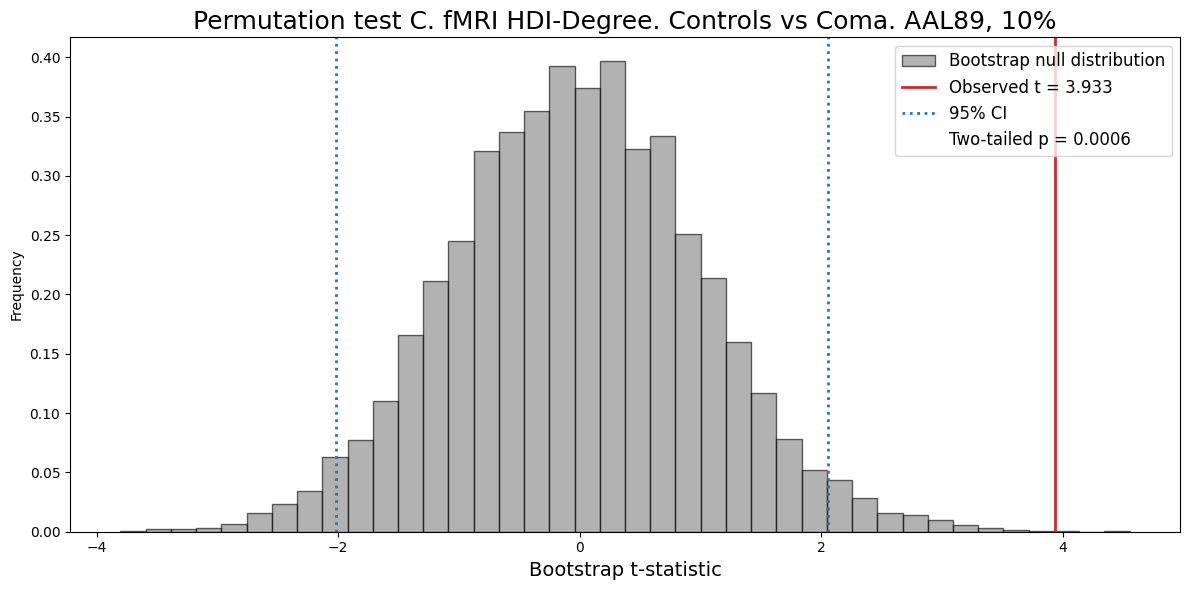

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram of bootstrap t-stats
ax.hist(
    boot_t_stats,
    bins=40,
    density=True,
    alpha=0.6,
    edgecolor="black",
    color="tab:gray",
    label="Bootstrap null distribution"
)

# Observed t-stat
ax.axvline(
    real_t,
    linestyle="-",
    color = "tab:red",
    linewidth=2,
    label=f"Observed t = {real_t:.3f}"
)


# CI
ax.axvline(ci_low, linestyle=":", linewidth=2, label="95% CI")
ax.axvline(ci_high, linestyle=":", linewidth=2)

# Dummy handle for p-value
pval_handle = Line2D(
    [], [], linestyle="none",
    label=f"Two-tailed p = {p_value_two_tailed:.3g}"
)

# Build legend
handles, labels = ax.get_legend_handles_labels()
handles.append(pval_handle)

ax.legend(handles=handles, loc="best", fontsize=12)

ax.set_xlabel("Bootstrap t-statistic", fontsize=14)
ax.set_ylabel("Frequency")
ax.set_title("Permutation test C. fMRI HDI-Degree. Controls vs Coma. AAL89, 10%", fontsize=18)

plt.tight_layout()
#plt.savefig("/E.1/C.1 fMRI AAL89 Bootstrap 10% 10k.png", dpi=300)
plt.show()


_“Would the observed group difference be likely if subjects were randomly assigned to groups but their anatomical structure was preserved?”_

We can generalize this script to all costs and metrics

In [13]:
null_stats_bootstrap = {cost: {metric: [] for metric in metrics} for cost in costs}

n_iterations = 10000

for cost in costs:
    for metric in metrics:
        all_hdi_values = list(HDI_results_fmri[cost][metric]['Controls'].values()) + list(HDI_results_fmri[cost][metric]['Coma'].values())
        
        for it in range(n_iterations):
            # Randomly shuffle labels
            shuffled = np.random.permutation(all_hdi_values) 
            # Split back into "fake" groups with same sizes as original
            fake_controls = shuffled[:len(controls_aal)]
            fake_coma = shuffled[len(controls_aal):]
            
            t_null, _ = ttest_ind(fake_controls, fake_coma)
            
            null_stats_bootstrap[cost][metric].append(t_null)

 

In [14]:
rows = []

for cost in costs:
    for metric in metrics:
        boot_t_stats = np.array(null_stats_bootstrap[cost][metric])

        real_t_stat = results_df.loc[
            (results_df.Cost == cost) &
            (results_df.Group_B == "Coma") & # we're always doing controls vs coma
            (results_df.Metric == metric),
            "T_stat"
        ].item()

        # percemtile of observed in the null distribution
        percentile = np.mean(boot_t_stats < real_t_stat) * 100

        # One and two-tailed p-values
        p_value_one_tailed = 1 - (percentile / 100)
        p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)

        # Cohen's D
        cohens_d_value = cohens_d(real_t_stat, boot_t_stats)

        # Confidence intervals
        ci_low = np.percentile(boot_t_stats, 2.5)
        ci_high = np.percentile(boot_t_stats, 97.5)

        rows.append({
            "Cost":cost,
            "Metric": metric,
            "Observed_t": real_t_stat,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "Cohens_D": cohens_d_value,
            "p_value": p_value_two_tailed
        })

results_bootstrap_fmri_df = pd.DataFrame(rows)

There's a lot of p-values that are zeroes, so we'll introduce a correction (Phipson and Smyth, 2010. https://doi.org/10.2202/1544-6115.1585)

In [16]:
rows = []

for cost in costs:
    for metric in metrics:
        boot_t_stats = np.array(null_stats_bootstrap[cost][metric])

        real_t_stat = results_df.loc[
            (results_df.Cost == cost) &
            (results_df.Group_B == "Coma") & # we're always doing controls vs coma
            (results_df.Metric == metric),
            "T_stat"
        ].item()

        # percemtile of observed in the null distribution
        percentile = np.mean(boot_t_stats < real_t_stat) * 100

        # One and two-tailed p-values
        p_value_one_tailed = 1 - (percentile / 100)
        p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)

        if p_value_two_tailed == 0:
            n = len(boot_t_stats)
            extreme = np.sum(np.abs(boot_t_stats) >= np.abs(real_t_stat))
            p_value_two_tailed = (extreme + 1) / (n+1)
        # Cohen's D
        cohens_d_value = cohens_d(real_t_stat, boot_t_stats)

        # Confidence intervals
        ci_low = np.percentile(boot_t_stats, 2.5)
        ci_high = np.percentile(boot_t_stats, 97.5)

        rows.append({
            "Cost":cost,
            "Metric": metric,
            "Observed_t": real_t_stat,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "Cohens_D": cohens_d_value,
            "p_value": p_value_two_tailed
        })

results_bootstrap_fmri_df = pd.DataFrame(rows)

In [ ]:
results_bootstrap_fmri_df.to_csv("/E/E.1/AAL_HDI_fMRI_tests.csv", index=False)

# TSPO graphs

Importing data

In [ ]:
tspo_matrix_path = "/Data/PET_Matrices/AAL" # Change accordingly 
list_tspo_cn = os.listdir(os.path.join(tspo_matrix_path, "Controls"))

controls_tspo_matrices = {}

for f in list_tspo_cn:
    #sub = 
    sub = f.split(".")[0]
    controls_tspo_matrices[sub] = np.loadtxt(os.path.join(tspo_matrix_path, "Controls", f), delimiter=",")

list_tspo_anox = os.listdir(os.path.join(tspo_matrix_path, "Anoxic"))

## Anoxic 

anoxic_tspo_matrices = {}

# --- Load matrices, excluding unwanted IDs ---
for f in list_tspo_anox:
    sub = f.split(".")[0]  # extract subject ID (before .csv or .txt)
    
    if sub not in anoxic_aal:
        print(f"Skipping excluded subject: {sub}")
        continue  # skip loading this subject
    
    file_path = os.path.join(tspo_matrix_path, "Anoxic", f)
    anoxic_tspo_matrices[sub] = np.loadtxt(file_path, delimiter=",")

## Traumatic

list_tspo_trau = os.listdir(os.path.join(tspo_matrix_path, "Traumatic"))

# --- Initialize container ---
traumatic_tspo_matrices = {}

# --- Load matrices, excluding unwanted IDs ---
for f in list_tspo_trau:
    sub = f.split(".")[0]  # extract subject ID (before .csv or .txt)
    
    if sub not in traumatic_aal:
        print(f"Skipping excluded subject: {sub}")
        continue  # skip loading this subject
    
    file_path = os.path.join(tspo_matrix_path, "Traumatic", f)
    traumatic_tspo_matrices[sub] = np.loadtxt(file_path, delimiter=",")

Skipping excluded subject: 09CD
Skipping excluded subject: 20MP
Skipping excluded subject: 25AY


In [19]:
controls_tspo_graphs = {cost:{sub: None for sub in controls_tspo_matrices.keys()} for cost in costs}
for cost in costs:
    for sub in controls_tspo_matrices.keys():
        controls_tspo_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(controls_tspo_matrices[sub], cost))

anoxic_tspo_graphs = {cost:{sub: None for sub in anoxic_tspo_matrices.keys()} for cost in costs}
for cost in costs:
    for sub in anoxic_tspo_matrices.keys():
            anoxic_tspo_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(anoxic_tspo_matrices[sub], cost))

traumatic_tspo_graphs = {cost:{sub: None for sub in traumatic_tspo_matrices.keys()} for cost in costs}
for cost in costs:
    for sub in traumatic_tspo_matrices.keys():
        traumatic_tspo_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(traumatic_tspo_matrices[sub], cost))

HDI - TSPO with control baseline

In [ ]:
# === HDI per subject, cost, and metric ===

metrics = ["d"] 

# === Containers ===
baseline_metrics_tspo = {m: {} for m in metrics}

HDI_results_tspo = {
    c: {m: {"Controls": {}, "Coma": {}} for m in metrics}
    for c in costs
}

# === Compute baseline metrics from controls ===
for cost in costs:
    for metric in metrics:
        baseline_metrics_tspo[metric][cost] = compute_baseline(
            controls_tspo_graphs[cost], metric
        )
        print(f"Computed baseline for cost {cost}, metric {metric}")

# === Define groups ===
groups = {
    "Controls": controls_tspo_graphs,
    "Anoxic": anoxic_tspo_graphs,
    "Traumatic": traumatic_tspo_graphs
}

# === Compute HDI ===
for cost in costs:
    for metric in metrics:
        baseline = baseline_metrics_tspo[metric][cost]

        for group_name, group_graphs in groups.items():

            dict_hdi = compute_HDI_ID(
                group_graphs[cost],
                baseline,
                metric
            )

            # Map groups → output structure
            target_group = "Controls" if group_name == "Controls" else "Coma"

            # Store results
            for sub, val in dict_hdi.items():
                HDI_results_tspo[cost][metric][target_group][sub] = val

            print(
                f"✓ {group_name} → {target_group}: "
                f"{metric} (cost={cost}) — {len(dict_hdi)} subjects"
            )

print("\nAll HDI computations complete.")


t-tests - _observed values_

In [ ]:

# === Collect results ===
rows = []

for cost in costs:
    for metric in metrics:

        # Base HDI data
        base_hdi = HDI_results_tspo[cost][metric]

        # === Rebuild groups (DO NOT mutate base_hdi) ===
        hdi_data = {}

        hdi_data["Controls"] = base_hdi.get("Controls", {})
        hdi_data["Coma"] = base_hdi.get("Coma", {})

        hdi_data["Anoxic"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in anoxic_aal
        }

        hdi_data["Traumatic"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in traumatic_aal
        }

        hdi_data["Favorable"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in favorable_group
        }

        hdi_data["Unfavorable"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in unfavorable_group
        }

        # === Run t-tests ===
        for group_a, group_b in group_comparisons:

            vals_a = list(hdi_data.get(group_a, {}).values())
            vals_b = list(hdi_data.get(group_b, {}).values())

            if len(vals_a) > 1 and len(vals_b) > 1:
                t_stat, p_val = ttest_ind(vals_a, vals_b, nan_policy="omit")
            else:
                t_stat, p_val = np.nan, np.nan

            rows.append({
                "Cost": cost,
                "Metric": metric,
                "Group_A": group_a,
                "Group_B": group_b,
                "N_A": len(vals_a),
                "N_B": len(vals_b),
                "T_stat": t_stat,
                "P_value": p_val
            })

# === Final DataFrame ===
results_df_tspo = pd.DataFrame(rows)

results_df_tspo


In [ ]:
results_df_tspo.to_csv("/E/HDI_PET_across_costs.csv", index=False)

Permutation test for PET graphs at 10%

In [60]:

all_hdi_values = list(HDI_results_tspo[0.1]['d']['Controls'].values()) + list(HDI_results_tspo[0.1]['d']['Coma'].values())

null_stats = []

for i in range(10000):
    # Randomly shuffle labels
    shuffled = np.random.permutation(all_hdi_values)
    
    # Split back into "fake" groups with same sizes as original
    fake_controls = shuffled[:len(controls_aal)]
    fake_coma = shuffled[len(controls_aal):]
    
    t_null, _ = ttest_ind(fake_controls, fake_coma)
    null_stats.append(t_null)

In [61]:
# get the bootstrap t_stats and the real slope
#boot_t_stats = xcoeffs[group][xcost][metric]

boot_t_stats = np.array(null_stats)

real_t =  results_df_tspo.loc[
    (results_df_tspo.Cost == 0.1) &
    (results_df_tspo.Group_B == "Coma") &
    (results_df_tspo.Metric == "d"),
    "T_stat"
].item()

# Percentile of the original slope in the bootstrapped distribution
percentile = np.mean(boot_t_stats < real_t) * 100

# One-tailed and two-tailed p-values
p_value_one_tailed = 1 - (percentile / 100)
p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)
#p_values_uncorrected.append(p_value_two_tailed) # we store each time


# Cohen's D
cohens_d_value = cohens_d(real_t, boot_t_stats)

# Confidence intervals
ci_low = np.percentile(boot_t_stats, 2.5)
ci_high = np.percentile(boot_t_stats, 97.5)


print(f"Observed t-stat: {real_t}")
print(f"Effect size: {cohens_d_value}")
print(f"CI: {ci_low}, {ci_high}")
print(f"p: {p_value_two_tailed}")
#print(f"raw p = {raw_p}, FDR-corrected p = {fdr_p}, significant: {reject} \n")


Observed t-stat: 5.916720203473945
Effect size: 5.742475505357738
CI: -2.0390867668186843, 2.002281303317513
p: 0.0


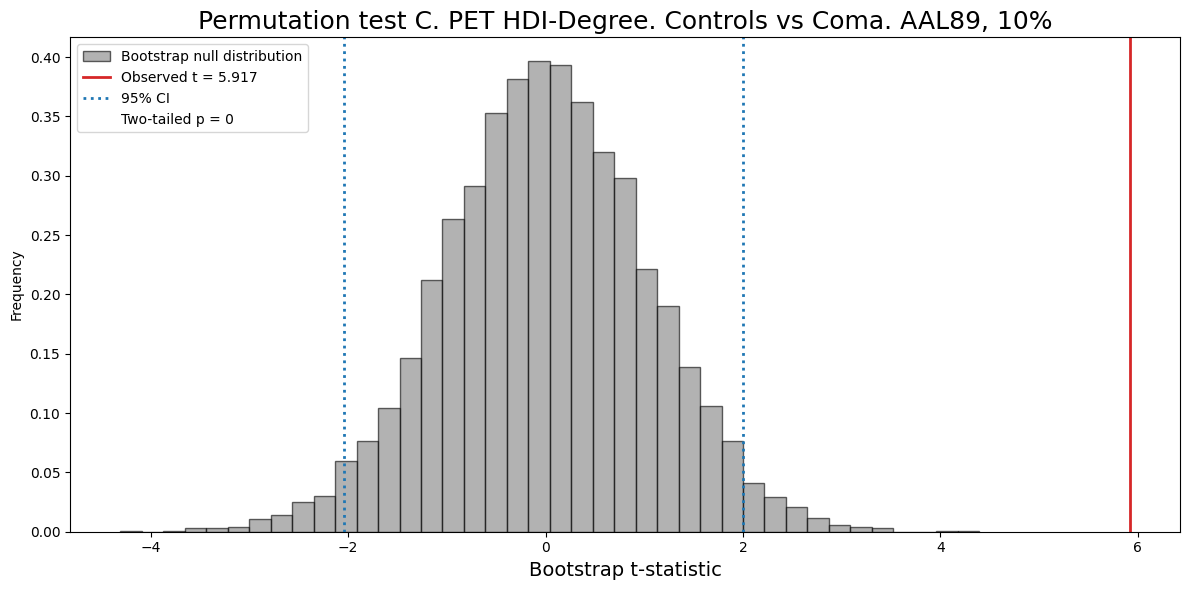

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram of bootstrap t-stats
ax.hist(
    boot_t_stats,
    bins=40,
    density=True,
    alpha=0.6,
    edgecolor="black",
    color="tab:gray",
    label="Bootstrap null distribution"
)

# Observed t-stat
ax.axvline(
    real_t,
    linestyle="-",
    color = "tab:red",
    linewidth=2,
    label=f"Observed t = {real_t:.3f}"
)


# CI
ax.axvline(ci_low, linestyle=":", linewidth=2, label="95% CI")
ax.axvline(ci_high, linestyle=":", linewidth=2)

# Dummy handle for p-value
pval_handle = Line2D(
    [], [], linestyle="none",
    label=f"Two-tailed p = {p_value_two_tailed:.3g}"
)

# Build legend
handles, labels = ax.get_legend_handles_labels()
handles.append(pval_handle)

ax.legend(handles=handles, loc="best")

ax.set_xlabel("Bootstrap t-statistic", fontsize=14)
ax.set_ylabel("Frequency")
ax.set_title("Permutation test C. PET HDI-Degree. Controls vs Coma. AAL89, 10%", fontsize=18)

plt.tight_layout()
#plt.savefig("/E/PET AAL89 Bootstrap 10% 10k.png", dpi=300)
plt.show()


General script

`null_stats_bootstrap` will be overwritten 

In [22]:
null_stats_bootstrap = {cost: {metric: [] for metric in metrics} for cost in costs}

n_iterations = 10000

for cost in costs:
    for metric in metrics:
        all_hdi_values = list(HDI_results_tspo[cost][metric]['Controls'].values()) + list(HDI_results_tspo[cost][metric]['Coma'].values())
        
        for it in range(n_iterations):
            # Randomly shuffle labels
            shuffled = np.random.permutation(all_hdi_values) 
            # Split back into "fake" groups with same sizes as original
            fake_controls = shuffled[:len(controls_aal)]
            fake_coma = shuffled[len(controls_aal):]
            
            t_null, _ = ttest_ind(fake_controls, fake_coma)
            
            null_stats_bootstrap[cost][metric].append(t_null)

 

In [ ]:
rows = []

for cost in costs:
    for metric in metrics:
        boot_t_stats = np.array(null_stats_bootstrap[cost][metric])

        real_t_stat = results_df_tspo.loc[
            (results_df_tspo.Cost == cost) &
            (results_df_tspo.Group_B == "Coma") & # we're always doing controls vs coma
            (results_df_tspo.Metric == metric),
            "T_stat"
        ].item()

        # percemtile of observed in the null distribution
        percentile = np.mean(boot_t_stats < real_t_stat) * 100

        # One and two-tailed p-values
        p_value_one_tailed = 1 - (percentile / 100)
        p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)

        # Cohen's D
        cohens_d_value = cohens_d(real_t_stat, boot_t_stats)

        # Confidence intervals
        ci_low = np.percentile(boot_t_stats, 2.5)
        ci_high = np.percentile(boot_t_stats, 97.5)

        rows.append({
            "Cost":cost,
            "Metric": metric,
            "Observed_t": real_t_stat,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "Cohens_D": cohens_d_value,
            "p_value": p_value_two_tailed
        })

results_bootstrap_tspo_df = pd.DataFrame(rows)
results_bootstrap_tspo_df

We apply the same correction and export

In [ ]:
rows = []

for cost in costs:
    for metric in metrics:
        boot_t_stats = np.array(null_stats_bootstrap[cost][metric])

        real_t_stat = results_df_tspo.loc[
            (results_df_tspo.Cost == cost) &
            (results_df_tspo.Group_B == "Coma") & # we're always doing controls vs coma
            (results_df_tspo.Metric == metric),
            "T_stat"
        ].item()

        # percemtile of observed in the null distribution
        percentile = np.mean(boot_t_stats < real_t_stat) * 100

        # One and two-tailed p-values
        p_value_one_tailed = 1 - (percentile / 100)
        p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)

        if p_value_two_tailed == 0:
            n = len(boot_t_stats)
            extreme = np.sum(np.abs(boot_t_stats) >= np.abs(real_t_stat))
            p_value_two_tailed = (extreme + 1) / (n+1)
        # Cohen's D
        cohens_d_value = cohens_d(real_t_stat, boot_t_stats)

        # Confidence intervals
        ci_low = np.percentile(boot_t_stats, 2.5)
        ci_high = np.percentile(boot_t_stats, 97.5)

        rows.append({
            "Cost":cost,
            "Metric": metric,
            "Observed_t": real_t_stat,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "Cohens_D": cohens_d_value,
            "p_value": p_value_two_tailed
        })

results_bootstrap_tspo_df = pd.DataFrame(rows)
results_bootstrap_tspo_df

In [ ]:
results_bootstrap_tspo_df.to_csv("/E/E.1/AAL_HDI_PET_tests.csv", index=False)